In [1]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import sqlite3

In [103]:
# import database
conn = sqlite3.connect('customer_churn.db')

sql_query= """
        select name
        from sqlite_master
        where type = 'table';
"""
tables = pd.read_sql(sql_query,conn)

#create dataframe for each table
for  table_name in tables['name']:
    df= pd.read_sql(f"select * from {table_name}", conn)
    globals()[f"df_{table_name}"] = df
    print(f"created dataframe : df_{table_name}")

# Close the connection when done
conn.close()


created dataframe : df_db_customer
created dataframe : df_db_subscription
created dataframe : df_db_support


In [104]:
import sqlite3
import pandas as pd

# Connect (or re-create) the database file
conn = sqlite3.connect('customer_churn.db')
cursor = conn.cursor()

# 1. Create tables
cursor.execute("""
CREATE TABLE IF NOT EXISTS db_customer (
    customerid TEXT,
    name TEXT,
    country TEXT,
    state TEXT,
    gender TEXT,
    dob TIMESTAMP,
    interests TEXT,
    pincode REAL
);
""")

cursor.execute("""
CREATE TABLE IF NOT EXISTS db_subscription (
    customerid TEXT,
    subscription_start_date TEXT,
    subscription_type TEXT,
    renewal_date TEXT,
    plan_type TEXT,
    contract_type TEXT,
    cancellation_date TEXT,
    cancellation_reason TEXT,
    monthly_charges REAL,
    cltv INTEGER,
    churn_score INTEGER
);
""")

cursor.execute("""
CREATE TABLE IF NOT EXISTS db_support (
    customerid TEXT,
    complaint_date TIMESTAMP,
    escalations TEXT,
    csat_score INTEGER,
    col_1 REAL,
    comment TEXT
);
""")

conn.commit()

# 2. Query all tables and store them as DataFrames
sql_query = "SELECT name FROM sqlite_master WHERE type = 'table';"
tables = pd.read_sql(sql_query, conn)

for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created DataFrame: df_{table_name}")

conn.close()

Created DataFrame: df_db_customer
Created DataFrame: df_db_subscription
Created DataFrame: df_db_support


In [105]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('customer_churn.db')
cursor = conn.cursor()

# 1. Insert Data into db_customer
cursor.executemany("""
INSERT OR IGNORE INTO db_customer VALUES (?, ?, ?, ?, ?, ?, ?, ?);
""", [
    ('0002-ORFBO', 'keshav', 'India', 'Maharashtra', 'Male', '1982-04-12 00:00:00', 'travel', 400001.0),
    ('0003-MKNFE', 'raghav', 'India', 'Karnataka', 'Male', '1995-11-23 00:00:00', 'sports', 560001.0),
    ('0004-TLHLJ', 'lalita', 'India', 'Delhi', 'Female', '1978-02-15 00:00:00', 'movie', 110001.0),
    ('0011-IGKFF', 'mohan', 'India', 'Nagaland', 'Male', '2001-08-30 00:00:00', 'gaming', 797001.0),
    ('0013-EXCHZ', 'mira', 'India', 'Delhi', 'Female', '1990-05-05 00:00:00', 'drama', 110002.0),
    ('0013-MHZWF', 'durga', 'India', 'Delhi', 'Women', '1988-12-10 00:00:00', 'music', 110003.0),
    ('0013-SMEOE', 'mina', 'India', 'Meghalaya', 'Female', '1976-09-21 00:00:00', 'reading', 793001.0),
    ('0014-BMAQU', 'madan', 'India', 'Rajasthan', 'Male', '1999-03-14 00:00:00', 'cooking', 302001.0),
    ('0015-UOCOJ', 'maya', 'Nepal', 'Kathmandu', 'Women', '1985-07-07 00:00:00', 'art', 44600.0),
    ('0016-QLJIS', 'arjun', 'Nepal', 'Kathmandu', 'Male', '1993-10-29 00:00:00', 'tech', 44601.0),
    ('0017-DINOC', 'shiva', 'India', 'Maharashtra', 'Men', '1997-01-22 00:00:00', 'fitness', 400002.0),
    ('0017-IUDMW', 'rangadevi', 'India', 'Karnataka', 'Female', '1981-06-18 00:00:00', 'nature', 560002.0),
    ('0018-NYROU', 'chitra', 'India', 'Telangana', 'Female', '2004-12-01 00:00:00', 'fashion', 500001.0),
    ('0019-EFAEP', 'raju', 'India', 'Meghalaya', 'Female', '1992-04-25 00:00:00', 'dance', 793002.0),
    ('0019-GFNTW', 'Madhav', 'India', 'Uttar Pradesh', 'Men', '1979-11-11 00:00:00', 'history', 208001.0),
    ('0020-INWCK', 'parvati', 'India', 'Delhi', 'Female', '1986-02-28 00:00:00', 'job', 110004.0),
    ('0020-JDNXP', 'rikim', 'India', 'Meghalaya', 'Female', '1994-08-19 00:00:00', 'food', 793003.0),
    ('0021-IKXGC', 'vishakha', 'India', 'Rajasthan', 'Female', '2000-09-02 00:00:00', 'design', 302002.0),
    ('0022-TCJCI', 'raghvendra', 'India', 'Telangana', 'Male', '1983-12-30 00:00:00', 'coding', 500002.0),
    ('0023-HGHWL', 'rishabh', 'India', 'Uttar Pradesh', 'Men', '1991-05-14 00:00:00', 'gaming', 208002.0),
    ('0023-UYUPN', 'sudevi', 'India', 'Maharashtra', 'Women', '1977-10-06 00:00:00', 'crafts', 400003.0)
])

# 2. Insert Data into db_subscription
cursor.executemany("""
INSERT OR IGNORE INTO db_subscription VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?);
""", [
    ('0002-ORFBO', '2021-03-15', 'Refferal', '2025-03-15', 'Standard', 'Annual', None, None, 65.6, 5234, 45),
    ('0003-MKNFE', '2020-08-01', 'Paid', '2024-08-01', 'Premium', 'Annual', '2024-09-10', 'Switched to competitor', 89.9, 6123, 78),
    ('0004-TLHLJ', '2022-11-20', 'Organic', '2025-11-20', 'Basic', 'Monthly', None, None, 29.9, 1450, 20),
    ('0011-IGKFF', '2019-05-10', 'Paid', '2025-05-10', 'Premium', 'Annual', None, None, 95.0, 7800, 15),
    ('0013-EXCHZ', '2023-01-05', 'Refferal', '2024-01-05', 'Standard', 'Monthly', '2024-02-28', 'Too expensive', 55.0, 2300, 82),
    ('0013-MHZWF', '2022-06-18', 'Paid', '2025-06-18', 'Standard', 'Annual', None, None, 60.0, 4100, 30),
    ('0013-SMEOE', '2021-09-30', 'Refferal', '2024-09-30', 'Basic', 'Monthly', '2024-11-15', 'Not enough content', 25.0, 1200, 88),
    ('0014-BMAQU', '2020-02-14', 'Organic', '2025-02-14', 'Premium', 'Annual', None, None, 90.0, 6800, 10),
    ('0015-UOCOJ', '2023-07-22', 'Organic', '2024-07-22', 'Standard', 'Monthly', None, None, 50.0, 1900, 40),
    ('0016-QLJIS', '2022-04-03', 'Organic', '2025-04-03', 'Basic', 'Annual', None, None, 30.0, 2100, 25),
    ('0017-DINOC', '2021-12-01', 'Organic', '2025-12-01', 'Premium', 'Annual', None, None, 95.0, 7200, 12),
    ('0017-IUDMW', '2023-03-17', 'Refferal', '2024-03-17', 'Standard', 'Monthly', '2024-05-01', 'Poor streaming quality', 50.0, 1800, 75),
    ('0018-NYROU', '2020-10-09', 'Organic', '2025-10-09', 'Standard', 'Annual', None, None, 65.0, 4500, 35),
    ('0019-EFAEP', '2022-08-25', 'Refferal', '2024-08-25', 'Basic', 'Monthly', '2024-10-31', 'Switched to competitor', 25.0, 1100, 91),
    ('0019-GFNTW', '2019-11-11', 'Paid', '2025-11-11', 'Premium', 'Annual', None, None, 99.0, 8500, 18),
    ('0020-INWCK', '2023-05-06', 'Organic', '2025-05-06', 'Standard', 'Monthly', None, None, 55.0, 2400, 50),
    ('0020-JDNXP', '2022-01-19', 'Organic', '2024-01-19', 'Premium', 'Annual', None, None, 85.0, 6000, 22),
    ('0021-IKXGC', '2021-07-07', 'Paid', '2025-07-07', 'Standard', 'Annual', None, None, 60.0, 4300, 28),
    ('0022-TCJCI', '2023-09-14', 'Refferal', '2024-09-14', 'Basic', 'Monthly', '2024-09-14', 'Forgot to cancel trial', 20.0, 900, 95),
    ('0023-HGHWL', '2020-06-23', 'Organic', '2025-06-23', 'Premium', 'Annual', None, None, 95.0, 7600, 14),
    ('0023-UYUPN', '2022-12-31', 'Paid', '2025-12-31', 'Standard', 'Monthly', None, None, 55.0, 3100, 42)
])

# 3. Insert Data into db_support
cursor.executemany("""
INSERT OR IGNORE INTO db_support VALUES (?, ?, ?, ?, ?, ?);
""", [
    ('0003-MKNFE', '2024-08-28 00:00:00', 'N', 1, 0.0, 'service issue'),
    ('0003-MKNFE', '2024-08-28 00:00:00', 'Y', 1, 0.0, 'demanded refund'),
    ('0013-EXCHZ', '2024-01-20 00:00:00', 'Y', 2, 0.0, None),
    ('0013-MHZWF', '2025-03-18 00:00:00', 'N', 4, 0.0, 'guidance to renew'),
    ('0013-SMEOE', '2024-11-01 00:00:00', 'N', 2, 0.0, None),
    ('0017-IUDMW', '2024-04-10 00:00:00', 'Y', 1, 0.0, None),
    ('0019-EFAEP', '2024-09-27 00:00:00', 'Y', 1, 0.0, None),
    ('0022-TCJCI', '2024-09-13 00:00:00', 'Y', 1, 0.0, None),
    ('0022-TCJCI', '2024-09-14 00:00:00', 'N', 1, 0.0, 'received refund')
])

# Save changes
conn.commit()

# Reload DataFrames
df_db_customer = pd.read_sql("SELECT * FROM db_customer;", conn)
df_db_subscription = pd.read_sql("SELECT * FROM db_subscription;", conn)
df_db_support = pd.read_sql("SELECT * FROM db_support;", conn)

conn.close()

print("Data inserted and DataFrames updated successfully!")

Data inserted and DataFrames updated successfully!


In [106]:
import sqlite3
import random
from datetime import datetime, timedelta
from faker import Faker
import pandas as pd
import numpy as np

fake = Faker('en_IN')  # Generates realistic Indian names, states, etc.

NUM_RECORDS = 1000

# 1. Generate Customer Data
states_list = ['Maharashtra', 'Karnataka', 'Delhi', 'Telangana', 'Uttar Pradesh', 'Meghalaya', 'Rajasthan', 'Nagaland']
genders = ['Male', 'Female']
interests_list = ['tech', 'gaming', 'sports', 'movies', 'reading', 'travel', 'cooking', 'music']

customers = []
customer_ids = []

for i in range(1, NUM_RECORDS + 1):
    cid = f"{i:04d}-CUST"
    customer_ids.append(cid)
    name = fake.first_name().lower()
    state = random.choice(states_list)
    gender = random.choice(genders)
    dob = fake.date_of_birth(minimum_age=18, maximum_age=65).strftime('%Y-%m-%d')
    interest = random.choice(interests_list)
    pincode = float(fake.postcode())  # Changed from fake.zipcode() to fake.postcode()
    
    customers.append((cid, name, 'India', state, gender, dob, interest, pincode))

# 2. Generate Subscription Data
subscriptions = []
plan_types = ['Basic', 'Standard', 'Premium']
contract_types = ['Monthly', 'Annual']
sub_types = ['Organic', 'Paid', 'Referral']
reasons = ['Too expensive', 'Switched to competitor', 'Poor service', 'Not enough content', 'Forgot to cancel trial']

for cid in customer_ids:
    start_date = fake.date_between(start_date='-3y', end_date='-6m')
    plan = random.choices(plan_types, weights=[0.3, 0.5, 0.2])[0]
    contract = random.choice(contract_types)
    sub_type = random.choice(sub_types)
    
    # Monthly charge based on plan
    base_charge = {'Basic': 29.9, 'Standard': 59.9, 'Premium': 99.9}[plan]
    monthly_charges = round(base_charge + random.uniform(-5, 5), 1)
    
    # Renewal date (1 year or 1 month after start)
    renewal_date = start_date + timedelta(days=365 if contract == 'Annual' else 30)
    
    # ~30% churn rate simulation
    is_churned = random.random() < 0.30
    if is_churned:
        cancel_date = start_date + timedelta(days=random.randint(30, 400))
        cancel_reason = random.choice(reasons)
        churn_score = random.randint(65, 98)
    else:
        cancel_date = None
        cancel_reason = None
        churn_score = random.randint(10, 60)
        
    cltv = int(monthly_charges * random.randint(12, 36))
    
    subscriptions.append((
        cid, 
        start_date.strftime('%Y-%m-%d'), 
        sub_type, 
        renewal_date.strftime('%Y-%m-%d'), 
        plan, 
        contract, 
        cancel_date.strftime('%Y-%m-%d') if cancel_date else None, 
        cancel_reason, 
        monthly_charges, 
        cltv, 
        churn_score
    ))

# 3. Generate Support Complaints Data (~35% of customers log tickets)
support_tickets = []
for cid, sub in zip(customer_ids, subscriptions):
    if random.random() < 0.35:
        num_tickets = random.randint(1, 3)
        for _ in range(num_tickets):
            comp_date = fake.date_between(start_date='-1y', end_date='today')
            escalated = random.choices(['Y', 'N'], weights=[0.3, 0.7])[0]
            csat = random.randint(1, 5)
            support_tickets.append((cid, comp_date.strftime('%Y-%m-%d 00:00:00'), escalated, csat, 0.0, 'service query'))

# 4. Insert into SQLite Database
conn = sqlite3.connect('customer_churn.db')
cursor = conn.cursor()

# Clear existing tables
cursor.execute("DROP TABLE IF EXISTS db_customer;")
cursor.execute("DROP TABLE IF EXISTS db_subscription;")
cursor.execute("DROP TABLE IF EXISTS db_support;")

cursor.execute("CREATE TABLE db_customer (customerid TEXT, name TEXT, country TEXT, state TEXT, gender TEXT, dob TIMESTAMP, interests TEXT, pincode REAL);")
cursor.execute("CREATE TABLE db_subscription (customerid TEXT, subscription_start_date TEXT, subscription_type TEXT, renewal_date TEXT, plan_type TEXT, contract_type TEXT, cancellation_date TEXT, cancellation_reason TEXT, monthly_charges REAL, cltv INTEGER, churn_score INTEGER);")
cursor.execute("CREATE TABLE db_support (customerid TEXT, complaint_date TIMESTAMP, escalations TEXT, csat_score INTEGER, col_1 REAL, comment TEXT);")

cursor.executemany("INSERT INTO db_customer VALUES (?, ?, ?, ?, ?, ?, ?, ?);", customers)
cursor.executemany("INSERT INTO db_subscription VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?);", subscriptions)
cursor.executemany("INSERT INTO db_support VALUES (?, ?, ?, ?, ?, ?);", support_tickets)

conn.commit()
conn.close()

print("Successfully populated SQLite database with 1,000 records!")

Successfully populated SQLite database with 1,000 records!


In [107]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 1021 entries, 0 to 1020
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   customerid  1021 non-null   str    
 1   name        1021 non-null   str    
 2   country     1021 non-null   str    
 3   state       1021 non-null   str    
 4   gender      1021 non-null   str    
 5   dob         1021 non-null   str    
 6   interests   1021 non-null   str    
 7   pincode     1021 non-null   float64
dtypes: float64(1), str(7)
memory usage: 63.9 KB


In [108]:
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
1016,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,food,793003.0
1017,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,design,302002.0
1018,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,coding,500002.0
1019,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,gaming,208002.0
1020,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,crafts,400003.0


In [109]:
#data clening for customer table 
#rename cutomer name
#removing the columns such as intrests and pincode which are nit relevent for analysis
# changing the data type of column dob in customer table
# data standerdisation in gender column
# Dealing with missing values in country column

df_db_customer= df_db_customer.rename(columns = {'name' : 'customer_name'})

In [110]:
df_db_customer.tail()

,customerid,customer_name,country,state,gender,dob,interests,pincode
1016,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,food,793003.0
1017,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,design,302002.0
1018,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,coding,500002.0
1019,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,gaming,208002.0
1020,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,crafts,400003.0


In [111]:
df_db_customer.drop(df_db_customer.columns[-2:], axis=1)


,customerid,customer_name,country,state,gender,dob
0,0001-CUST,balvan,India,Telangana,Female,1964-05-02
1,0002-CUST,ayushman,India,Nagaland,Female,1962-02-26
2,0003-CUST,vedika,India,Maharashtra,Female,1980-06-11
3,0004-CUST,warda,India,Meghalaya,Female,1975-04-20
4,0005-CUST,girish,India,Maharashtra,Female,1971-03-20
...,...,...,...,...,...,...
1016,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00
1017,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00
1018,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00
1019,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00


In [112]:
#removing the columns such as intrests and pincode which are nit relevent for analysis
df_db_customer.drop(columns = ['interests' , 'pincode'], inplace =True)

In [113]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 1021 entries, 0 to 1020
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   customerid     1021 non-null   str  
 1   customer_name  1021 non-null   str  
 2   country        1021 non-null   str  
 3   state          1021 non-null   str  
 4   gender         1021 non-null   str  
 5   dob            1021 non-null   str  
dtypes: str(6)
memory usage: 48.0 KB


In [115]:
# Convert dob column using format='mixed' to handle mixed date-time strings cleanly
df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'], format='mixed')

In [ ]:
df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [116]:
#Data standerdization of gender column
df_db_customer['gender'] = df_db_customer['gender'].replace({ 'Men' : 'Male' , 'Women' : 'Female'})


In [117]:
df_db_customer['gender'].unique()

<StringArray>
['Female', 'Male']
Length: 2, dtype: str

In [118]:
# daeling with missing values although there are none here but its for future referance
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob


In [119]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0001-CUST,2024-03-21,Organic,2025-03-21,Premium,Annual,NaN,NaN,99.6,1394,56
1,0002-CUST,2025-04-17,Organic,2026-04-17,Standard,Annual,NaN,NaN,64.4,2254,36
2,0003-CUST,2025-05-17,Organic,2026-05-17,Basic,Annual,NaN,NaN,28.5,883,38
3,0004-CUST,2024-05-08,Paid,2025-05-08,Standard,Annual,NaN,NaN,64.3,1543,52
4,0005-CUST,2023-09-27,Paid,2024-09-26,Standard,Annual,NaN,NaN,63.1,1956,22


In [120]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 1021 entries, 0 to 1020
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               1021 non-null   str    
 1   subscription_start_date  1021 non-null   str    
 2   subscription_type        1021 non-null   str    
 3   renewal_date             1021 non-null   str    
 4   plan_type                1021 non-null   str    
 5   contract_type            1021 non-null   str    
 6   cancellation_date        331 non-null    str    
 7   cancellation_reason      331 non-null    str    
 8   monthly_charges          1021 non-null   float64
 9   cltv                     1021 non-null   int64  
 10  churn_score              1021 non-null   int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 87.9 KB


In [121]:
# data cleaning for subscription table
# date columns data types need to be changed


In [122]:
date_col = ['subscription_start_date', 'renewal_date' , 'cancellation_date']
df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)

In [123]:
df_db_support

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0002-CUST,2026-03-19 00:00:00,Y,4,0.0,service query
1,0002-CUST,2026-01-22 00:00:00,N,3,0.0,service query
2,0003-CUST,2026-06-15 00:00:00,Y,4,0.0,service query
3,0003-CUST,2025-09-14 00:00:00,N,5,0.0,service query
4,0004-CUST,2025-10-25 00:00:00,Y,4,0.0,service query
...,...,...,...,...,...,...
755,0013-SMEOE,2024-11-01 00:00:00,N,2,0.0,NaN
756,0017-IUDMW,2024-04-10 00:00:00,Y,1,0.0,NaN
757,0019-EFAEP,2024-09-27 00:00:00,Y,1,0.0,NaN
758,0022-TCJCI,2024-09-13 00:00:00,Y,1,0.0,NaN


In [124]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 760 entries, 0 to 759
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customerid      760 non-null    str    
 1   complaint_date  760 non-null    str    
 2   escalations     760 non-null    str    
 3   csat_score      760 non-null    int64  
 4   col_1           760 non-null    float64
 5   comment         755 non-null    str    
dtypes: float64(1), int64(1), str(4)
memory usage: 35.8 KB


In [125]:
#Data cleaning for support table
# complaint_date data type is sting we need to change it into datetime
# we can drop last two columns because we don't need them

In [126]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])


In [127]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 760 entries, 0 to 759
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      760 non-null    str           
 1   complaint_date  760 non-null    datetime64[us]
 2   escalations     760 non-null    str           
 3   csat_score      760 non-null    int64         
 4   col_1           760 non-null    float64       
 5   comment         755 non-null    str           
dtypes: datetime64[us](1), float64(1), int64(1), str(3)
memory usage: 35.8 KB


In [128]:
df_db_support.drop(columns = ['col_1' , 'comment'] , inplace = True)

In [129]:
# FEATURE ENGINEERING AND DATA ANALYSIS

In [130]:
# Craeating a churn flag column
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna() , 1 , 0)

In [131]:
df_db_subscription.tail()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
1016,0020-JDNXP,2022-01-19,Organic,2024-01-19,Premium,Annual,NaT,NaN,85.0,6000,22,0
1017,0021-IKXGC,2021-07-07,Paid,2025-07-07,Standard,Annual,NaT,NaN,60.0,4300,28,0
1018,0022-TCJCI,2023-09-14,Refferal,2024-09-14,Basic,Monthly,2024-09-14,Forgot to cancel trial,20.0,900,95,1
1019,0023-HGHWL,2020-06-23,Organic,2025-06-23,Premium,Annual,NaT,NaN,95.0,7600,14,0
1020,0023-UYUPN,2022-12-31,Paid,2025-12-31,Standard,Monthly,NaT,NaN,55.0,3100,42,0


In [132]:
# Remove duplicate records from source tables
df_db_customer = df_db_customer.drop_duplicates(subset=['customerid'])
df_db_subscription = df_db_subscription.drop_duplicates(subset=['customerid'])

# Ensure support table only keeps the latest complaint per customer (already handled in cell 32)
df_db_support = (
    df_db_support
    .sort_values('complaint_date')
    .drop_duplicates(subset=['customerid'], keep='last')
)

In [133]:
# Merging all the dataframes 
df = (df_db_subscription
    .merge(df_db_customer, on='customerid', how='left')
    .merge(df_db_support, on='customerid', how='left'))

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1021 entries, 0 to 1020
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               1021 non-null   str           
 1   subscription_start_date  1021 non-null   datetime64[us]
 2   subscription_type        1021 non-null   str           
 3   renewal_date             1021 non-null   datetime64[us]
 4   plan_type                1021 non-null   str           
 5   contract_type            1021 non-null   str           
 6   cancellation_date        331 non-null    datetime64[us]
 7   cancellation_reason      331 non-null    str           
 8   monthly_charges          1021 non-null   float64       
 9   cltv                     1021 non-null   int64         
 10  churn_score              1021 non-null   int64         
 11  churn_flag               1021 non-null   int64         
 12  customer_name            1021 non-null   str 

In [134]:
#because support table has multiple rows of record if same customer complains again
#thus we are getting 23 valuse instaed of 21 values
# we need to groupby it and then sort to keep the last one


In [135]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')
df_db_support=df_db_support.sort_values('complaint_date').drop_duplicates('customerid',keep='last')

In [136]:
df = (df_db_subscription
    .merge(df_db_customer, on='customerid', how='left')
    .merge(df_db_support, on='customerid', how='left'))

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1021 entries, 0 to 1020
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               1021 non-null   str           
 1   subscription_start_date  1021 non-null   datetime64[us]
 2   subscription_type        1021 non-null   str           
 3   renewal_date             1021 non-null   datetime64[us]
 4   plan_type                1021 non-null   str           
 5   contract_type            1021 non-null   str           
 6   cancellation_date        331 non-null    datetime64[us]
 7   cancellation_reason      331 non-null    str           
 8   monthly_charges          1021 non-null   float64       
 9   cltv                     1021 non-null   int64         
 10  churn_score              1021 non-null   int64         
 11  churn_flag               1021 non-null   int64         
 12  customer_name            1021 non-null   str 

In [137]:
df.to_csv('exported_churn_data.csv', index=False)

In [138]:
#Data Analysis
#Churn Analysis

In [139]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

In [140]:
churn_rate= df['churn_flag'].mean() * 100
print("customer churn rate = " ,round(churn_rate, 2),"%")

customer churn rate =  32.42 %


In [141]:
Customer_retention_rate = 100 - churn_rate
print("customer retention rate = " ,round(Customer_retention_rate, 2),"%")

customer retention rate =  67.58 %


In [142]:
churn_by_plan=(df.groupby('plan_type')['churn_flag'].mean().mul(100)
                .round(2).reset_index(name= 'churn_pct_rate'))
churn_by_plan

,plan_type,churn_pct_rate
0,Basic,33.77
1,Premium,31.70
2,Standard,31.92


In [143]:
churn_by_plan=(df.groupby('plan_type')
               .agg(churn_pct_rate = ('churn_flag', lambda x :round(x.mean()*100,2)),
                   total_revenue=('monthly_charges', 'sum'),
                    customer_count=('customerid', 'count')
                   
                   ).reset_index())
churn_by_plan

,plan_type,churn_pct_rate,total_revenue,customer_count
0,Basic,33.77,8935.7,302
1,Premium,31.70,22236.0,224
2,Standard,31.92,29658.1,495


In [144]:
churn_by_state = (
    df.groupby('state')
    .agg(
        churn_pct_rate=('churn_flag', lambda x: round(x.mean() * 100, 2)),
        total_revenue=('monthly_charges', 'sum'),
        customer_count=('customerid', 'count')
    )
    .reset_index()
)


churn_by_state

,state,churn_pct_rate,total_revenue,customer_count
0,Delhi,36.59,6997.3,123
1,Karnataka,40.00,8445.9,140
2,Kathmandu,0.00,80.0,2
3,Maharashtra,33.61,7438.6,122
4,Meghalaya,35.04,6413.5,117
5,Nagaland,30.66,8314.8,137
6,Rajasthan,28.69,7182.7,122
7,Telangana,31.39,8217.7,137
8,Uttar Pradesh,23.14,7739.3,121


In [145]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

In [146]:
# ARPU averagw revenue per user
Average_revenue=df['monthly_charges'].mean()
print(" Avg Reveneue per User = " , round(Average_revenue,2))

 Avg Reveneue per User =  59.58


In [147]:
today = pd.Timestamp.today()
df['tenure_days']= np.where(df['cancellation_date'].notna(),
                     (df['cancellation_date'] - df['subscription_start_date']).dt.days,
                     (today - df['subscription_start_date']).dt.days)
Average_tenure= df['tenure_days'].mean()
print("Average tenure days per customer = " ,round((Average_tenure),0))

Average tenure days per customer =  471.0


In [148]:
df.tail()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days
1016,0020-JDNXP,2022-01-19,Organic,2024-01-19,Premium,Annual,NaT,NaN,85.0,6000,...,rikim,India,Meghalaya,Female,1994-08-19,NaT,NaN,NaN,NaN,1649.0
1017,0021-IKXGC,2021-07-07,Paid,2025-07-07,Standard,Annual,NaT,NaN,60.0,4300,...,vishakha,India,Rajasthan,Female,2000-09-02,NaT,NaN,NaN,NaN,1845.0
1018,0022-TCJCI,2023-09-14,Refferal,2024-09-14,Basic,Monthly,2024-09-14,Forgot to cancel trial,20.0,900,...,raghvendra,India,Telangana,Male,1983-12-30,2024-09-14,N,1.0,1.0,366.0
1019,0023-HGHWL,2020-06-23,Organic,2025-06-23,Premium,Annual,NaT,NaN,95.0,7600,...,rishabh,India,Uttar Pradesh,Male,1991-05-14,NaT,NaN,NaN,NaN,2224.0
1020,0023-UYUPN,2022-12-31,Paid,2025-12-31,Standard,Monthly,NaT,NaN,55.0,3100,...,sudevi,India,Maharashtra,Female,1977-10-06,NaT,NaN,NaN,NaN,1303.0


In [149]:
#Revenue Lost--Bescause of churn users
revenue_at_risk=df.loc[df['churn_flag']==1,'monthly_charges'].sum()
print("revenue at risk =" ,revenue_at_risk)

revenue at risk = 19523.7


In [150]:
#Escalation rate
escaltion_rate=(df['escalations'] == 'Y').mean() * 100
print("Escalation rate = " , round((escaltion_rate),2),"%")

Escalation rate =  11.07 %


In [151]:
#Average complaints per user
average_complaints= df['complaint_count'].count()/df['customerid'].nunique()
print("Average complaints per user=",round((average_complaints),2))

Average complaints per user= 0.37


In [152]:
# 1. Re-merge escalations column from df_db_support to restore original 'Y'/'N' values
df['escalations'] = df['customerid'].map(df_db_support.set_index('customerid')['escalations'])

# 2. Map 'Y' -> 1, 'N' -> 0, and missing (no support complaint) -> 0
df['escalations_binary'] = df['escalations'].map({'Y': 1, 'N': 0}).fillna(0).astype(int)

# 3. Calculate correlation
correlation = df['escalations_binary'].corr(df['churn_flag'])
print("Correlation between Escalations and Churn:", round(correlation, 4))

Correlation between Escalations and Churn: -0.0576


In [153]:
#creating a new column called churn_risk using exixting col 'churn_score'
conditions=[
            (df['churn_score'] < 50),
            (df['churn_score'] >= 50) & (df['churn_score'] < 70),
            (df['churn_score'] >= 50)
]

choices = ['Low','Med','High']
df['churn_risk'] = np.select(conditions,choices,default='Unknown')

In [154]:
df[['churn_score','churn_risk']].tail()

,churn_score,churn_risk
1016,22,Low
1017,28,Low
1018,95,High
1019,14,Low
1020,42,Low


In [155]:
#Visualization using Matplotlib and seaborn
df_visual = df.copy() # creating a copy for contingencies


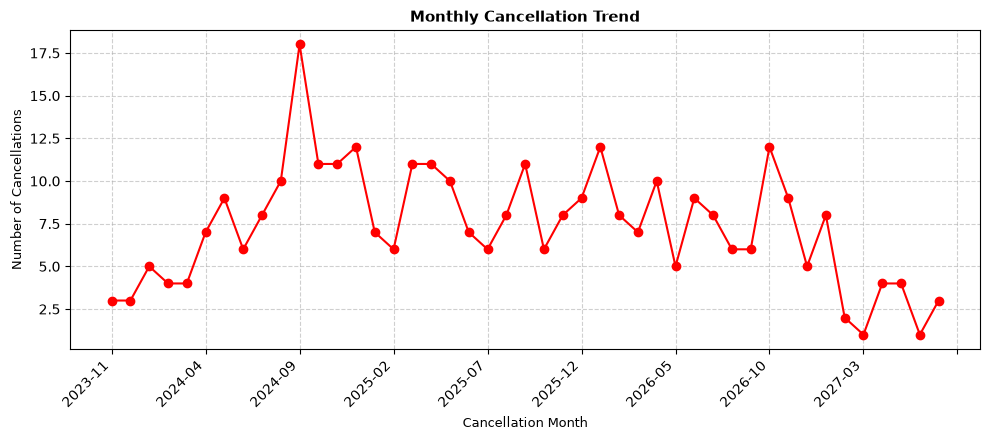

In [169]:
import matplotlib.ticker as ticker

plt.figure(figsize=(10, 4.5))
plt.plot(
    monthly_cancellations['cancellation_month'], 
    monthly_cancellations['cancellation_count'], 
    marker='o', 
    color='red', 
    linewidth=1.5
)

plt.title('Monthly Cancellation Trend', fontsize=11, fontweight='bold')
plt.xlabel('Cancellation Month', fontsize=9)
plt.ylabel('Number of Cancellations', fontsize=9)
plt.grid(True, linestyle='--', alpha=0.6)

# --- FIX X-AXIS OVERLAP ---
ax = plt.gca()
# Show a maximum of 10-12 tick labels on the x-axis
ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=12))
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

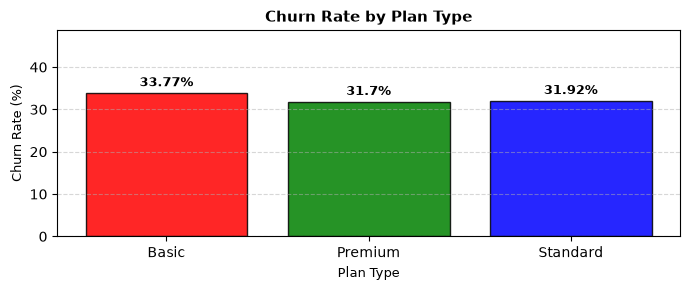

In [157]:
# 1. Aggregate churn rate and customer count by plan_type
churn_by_plan = (
    df_visual.groupby('plan_type')
    .agg(
        churn_pct=('churn_flag', lambda x: round(x.mean() * 100, 2)),
        total_churned=('churn_flag', 'sum'),
        total_customers=('customerid', 'count')
    )
    .reset_index()
)

# 2. Plot Churn Rate by Plan Type
plt.figure(figsize=(7, 3))
bars = plt.bar(
    churn_by_plan['plan_type'], 
    churn_by_plan['churn_pct'], 
    color=['Red', 'Green', 'Blue'], 
    edgecolor='black',
    alpha=0.85
)

# Add data labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2, 
        yval + 1, 
        f"{yval}%", 
        ha='center', 
        va='bottom', 
        fontsize=9, 
        fontweight='bold'
    )

plt.title('Churn Rate by Plan Type', fontsize=11, fontweight='bold')
plt.xlabel('Plan Type', fontsize=9)
plt.ylabel('Churn Rate (%)', fontsize=9)
plt.ylim(0, max(churn_by_plan['churn_pct']) + 15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

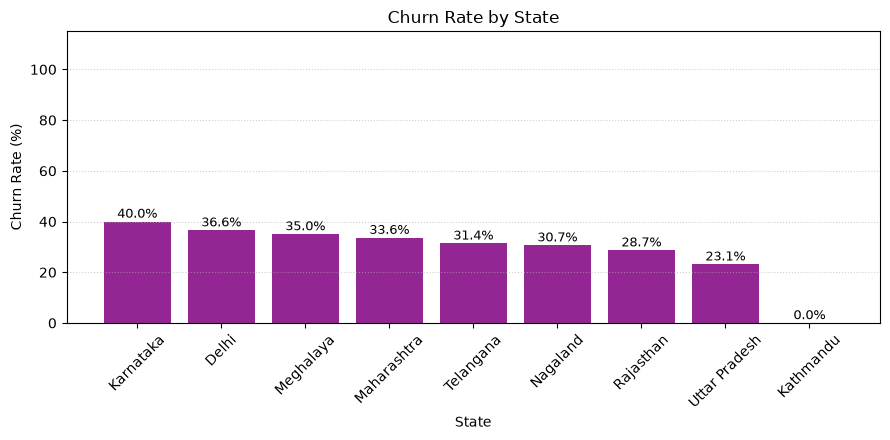

In [158]:
# Group data to get churn percentage by state
state_churn = df_visual.groupby('state')['churn_flag'].mean() * 100
state_churn = state_churn.sort_values(ascending=False)

# Plotting
plt.figure(figsize=(9, 4.5))
bars = plt.bar(state_churn.index, state_churn.values, color='purple', alpha=0.85)

# Add values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1.5, f"{height:.1f}%", ha='center', fontsize=9)

# Labels and style
plt.title('Churn Rate by State', fontsize=12)
plt.xlabel('State')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 115)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [159]:
#Viusalizition through seaborn

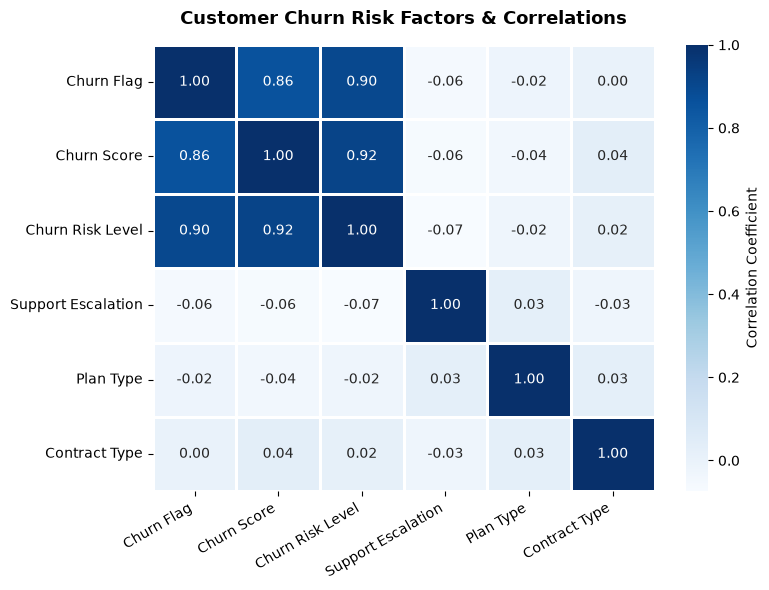

In [160]:
# 1. Prepare a clean copy with encoded categories for analysis
df_corr = df.copy()

# Map binary/categorical columns into clear numeric representations
df_corr['escalations_num'] = df_corr['escalations'].map({'Y': 1, 'N': 0}).fillna(0)
df_corr['churn_risk_num'] = df_corr['churn_risk'].map({'Low': 1, 'Med': 2, 'High': 3})

# Map plan & contract types to numeric codes
df_corr['plan_type_num'] = df_corr['plan_type'].astype('category').cat.codes
df_corr['contract_type_num'] = df_corr['contract_type'].astype('category').cat.codes

# 2. Select key columns and rename them for stakeholder clarity
cols_map = {
    'churn_flag': 'Churn Flag',
    'churn_score': 'Churn Score',
    'churn_risk_num': 'Churn Risk Level',
    'escalations_num': 'Support Escalation',
    'plan_type_num': 'Plan Type',
    'contract_type_num': 'Contract Type'
}

df_selected = df_corr[list(cols_map.keys())].rename(columns=cols_map)
corr = df_selected.corr()

# 3. Plot clean correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr, 
    annot=True, 
    fmt='.2f', 
    cmap='Blues', 
    linewidths=0.8,
    cbar_kws={'label': 'Correlation Coefficient'}
)

plt.title('Customer Churn Risk Factors & Correlations', fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

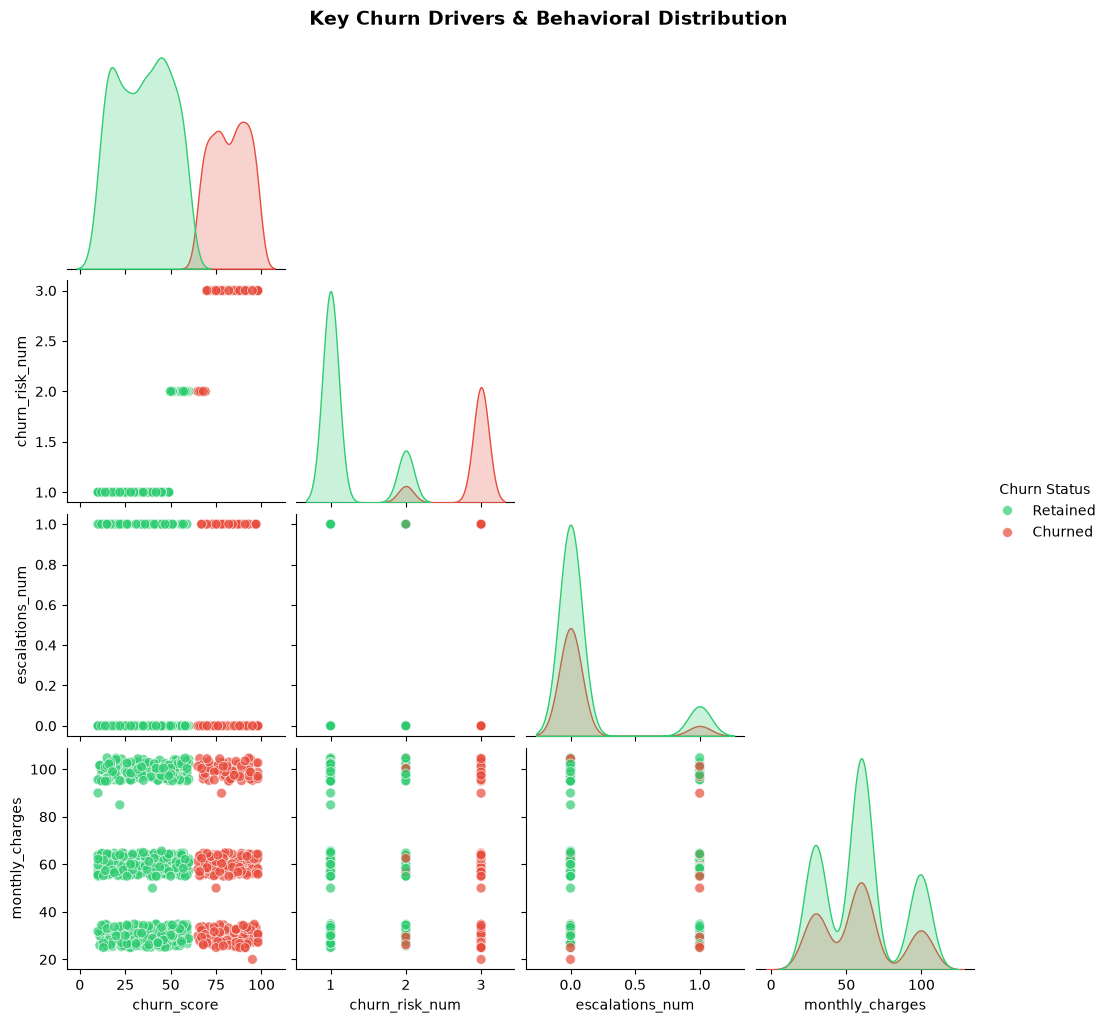

In [161]:
# 1. Prepare data with clear, stakeholder-friendly column names
df_pair = df.copy()

df_pair['churn_risk_num'] = df_pair['churn_risk'].map({'Low': 1, 'Med': 2, 'High': 3})
df_pair['escalations_num'] = df_pair['escalations'].map({'Y': 1, 'N': 0}).fillna(0)
df_pair['Churn Status'] = df_pair['churn_flag'].map({1: 'Churned', 0: 'Retained'})

# 2. Select key variables to keep the pairplot legible
pair_cols = ['churn_score', 'churn_risk_num', 'escalations_num', 'monthly_charges', 'Churn Status']

# 3. Build a clean, readable PairPlot
g = sns.pairplot(
    df_pair[pair_cols], 
    hue='Churn Status', 
    palette={'Churned': '#e74c3c', 'Retained': '#2ecc71'},
    corner=True,             # Drops duplicate top triangle for a cleaner look
    diag_kind='kde',         # Smooth density curves on the diagonal
    plot_kws={'alpha': 0.7, 's': 50}
)

# 4. Refine title and layout
g.fig.suptitle('Key Churn Drivers & Behavioral Distribution', y=1.02, fontsize=14, fontweight='bold')

plt.show()

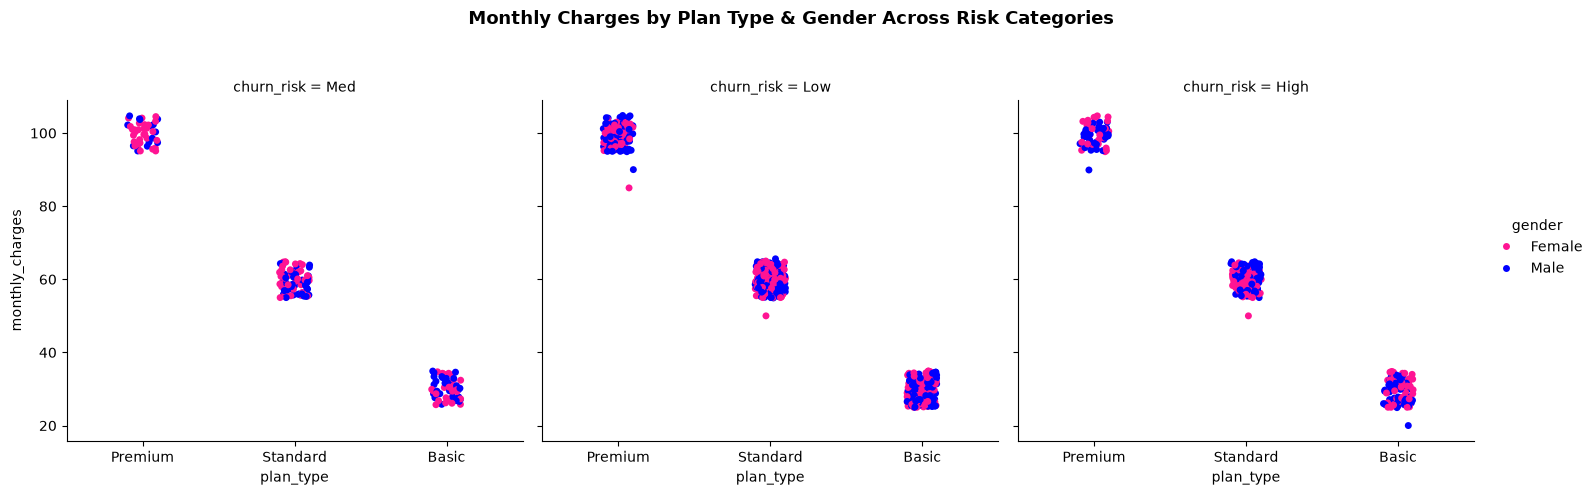

In [168]:
# Catplot / FacetGrid -- Multi-dimensional comparison
g = sns.catplot(
    data=df_visual, 
    x='plan_type', 
    y='monthly_charges', 
    hue='gender', 
    col='churn_risk',
    palette={'Female': 'deeppink', 'Male': 'Blue'}
)

g.fig.subplots_adjust(top=0.8)
g.fig.suptitle('Monthly Charges by Plan Type & Gender Across Risk Categories', fontsize=13, fontweight='bold')

plt.show()